# Stroke Risk Prediction Using Machine Learning

This project develops and evaluates multiclass machine-learning models for predicting stroke-risk category (Low, Moderate, or High) from demographic, clinical, behavioral, and health-related variables in the *Stroke Risk Prediction Dataset*. The analysis begins with data quality assessment and exploratory analysis and progresses through preprocessing, model development, hyperparameter tuning, evaluation, error analysis, calibration, and model interpretation.

First, data are separated into training and test sets. Then, preprocessing is fitted on the training data to prevent data leakage from variables that either directly informed stroke risk category (i.e., "*Stroke Risk Score*") or were directly informed by it (i.e., AI and doctor consultation recommendations). Multiple modeling approaches are compared, including logistic regression, random forest, and XGBoost, with performance evaluated using a variety of indicators (e.g., accuracy, balanced accuracy, class-specific recall, macro F1, confusion matrices, calibration, Brier score, and multiclass log loss). The final model is further examined using [Lundberg & Lee's (2017)](https://arxiv.org/abs/1705.07874) Shapely Additive Explanations (SHAP) to understand which features contribute most strongly to predictions and how those relationships vary across risk categories.

***Attribution**: This analysis uses the *Stroke Risk Prediction Dataset* created and uploaded to Kaggle by Mobeen Fatimah. The dataset is synthetically generated for educational, research, and machine-learning purposes and is licensed under **CC BY-SA 4.0**.*

*Source: [Kaggle — Stroke Risk Prediction Dataset](https://www.kaggle.com/datasets/mobeenfatimah/stroke-risk-prediction-dataset)*
*License: [Creative Commons Attribution-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-sa/4.0/)*

## Step 1 - Data Preparation and Descriptive Analyses

For this project, we will need to use the following Python libraries:
- [pandas](https://pandas.pydata.org/docs/)
- [numpy](https://numpy.org/doc/stable/)
- [matplotlib](https://matplotlib.org/stable/index.html)
- [sklearn](https://scikit-learn.org/0.21/documentation.html)
- [xgboost](https://xgboost.readthedocs.io/en/stable/)
- [shap](https://shap.readthedocs.io/en/latest/)

We will start by importing these libraries as well as the dataset itself, saved in a data folder in our project workspace. We can get some top-level information about the dataset right now.

In [275]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import xgboost as xg
import shap

df = pd.read_csv("./data/stroke_risk_prediction_dataset.csv")

# This option ensures that our notebook will display all rows in our tables instead of truncating them.
pd.set_option("display.max_rows", None)

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient_ID                    50000 non-null  int64  
 1   Age                           49781 non-null  float64
 2   Gender                        50000 non-null  str    
 3   Country                       50000 non-null  str    
 4   Height_cm                     48475 non-null  float64
 5   Weight_kg                     48477 non-null  float64
 6   BMI                           50000 non-null  float64
 7   Blood_Pressure_Systolic       50000 non-null  int64  
 8   Blood_Pressure_Diastolic      50000 non-null  int64  
 9   Heart_Rate                    50000 non-null  int64  
 10  Blood_Glucose                 49040 non-null  float64
 11  HbA1c                         48994 non-null  float64
 12  Total_Cholesterol             48996 non-null  float64
 13  HDL         

We see that the dataset contains 40 columns of data from 50,000 individual patients. Variables include numeric as well as categorical data, and some have missing data. Let's examing exactly how much missing data we have.

In [276]:
df.isna().sum().loc[lambda x: x > 0].sort_values(ascending=False)

Height_cm                  1525
Weight_kg                  1523
Exercise_Hours_Per_Week    1054
Medication_Adherence       1051
Daily_Walking_Minutes      1051
LDL                        1050
Triglycerides              1032
Sleep_Hours                1026
HDL                        1021
HbA1c                      1006
Total_Cholesterol          1004
Blood_Glucose               960
Age                         219
dtype: int64

We should also check for duplicate entries.

In [277]:
df.duplicated().sum()

np.int64(0)

The dataset contains unique entries only. We can also gather some basic descriptive information for our numeric and categorical variables. Let's start with the numeric data.

In [278]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Patient_ID,50000.0,25000.500000,14433.901067,1.0,12500.75,25000.5,37500.25,50000.0
Age,49781.0,53.903096,21.070953,18.0,36.00,54.0,72.00,90.0
Height_cm,48475.0,170.125582,14.484573,145.0,157.60,170.1,182.80,195.0
Weight_kg,48477.0,87.506141,24.565490,45.0,66.20,87.5,108.80,130.0
BMI,50000.0,30.901386,10.254560,11.9,22.70,30.1,37.80,61.5
Blood_Pressure_Systolic,50000.0,135.061420,20.526562,100.0,117.00,135.0,153.00,170.0
Blood_Pressure_Diastolic,50000.0,84.840620,14.685149,60.0,72.00,85.0,98.00,110.0
Heart_Rate,50000.0,82.521020,16.141082,55.0,68.00,83.0,97.00,110.0
Blood_Glucose,49040.0,145.031421,43.405484,70.0,107.40,145.1,182.70,220.0
HbA1c,48994.0,7.488103,1.733379,4.5,6.00,7.5,9.00,10.5


To better understand the categorical data, we'll extract variables with the string datatype from the dataset, create a list of their descriptive features (e.g., categories, counts, percentages), and then display the list as a dataframe.

In [279]:
categorical_cols = df.select_dtypes(include="str").columns

categorical_summary = []

for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    percentages = df[col].value_counts(normalize=True, dropna=False) * 100

    for category in counts.index:
        categorical_summary.append({
            "Variable": col,
            "Category": category,
            "Count": counts[category],
            "Percent": percentages[category]
        })

categorical_summary = pd.DataFrame(categorical_summary)

categorical_summary["Percent"] = categorical_summary["Percent"].round(1)

categorical_summary

,Variable,Category,Count,Percent
0,Gender,Other,16791,33.6
1,Gender,Male,16768,33.5
2,Gender,Female,16441,32.9
3,Country,Italy,2058,4.1
4,Country,Singapore,2047,4.1
5,Country,India,2041,4.1
6,Country,Bangladesh,2040,4.1
7,Country,Pakistan,2037,4.1
8,Country,Indonesia,2029,4.1
9,Country,South Africa,2027,4.1


In summary, we see that the *Stroke Risk Prediction Dataset* includes patient demographics, health data, and clinical recommendations. There are missing values throughout the dataset, but there are no duplicate records.

`Stroke_Risk` appears to be the target variable in this dataset. Next, we need to investigate the relationships between `Stroke_Risk` and variables that may potentially create target leakage. Let's start by visualizing the relationship between `Stroke_Risk` and `Stroke_Risk_Score` using a box plot.


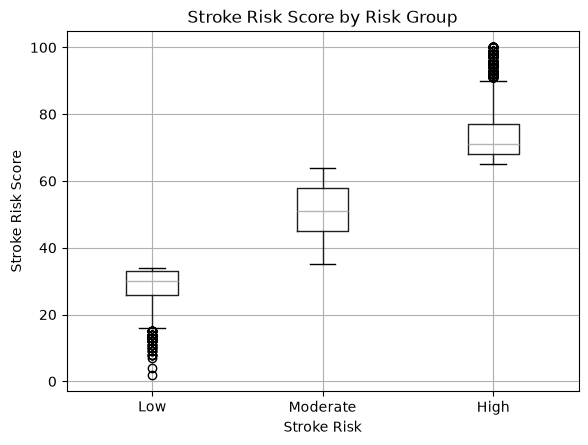

In [280]:
plot_order = ["Low", "Moderate", "High"]

df.assign(
    Stroke_Risk=pd.Categorical(
        df["Stroke_Risk"],
        categories=plot_order,
        ordered=True
    )
).boxplot(
    column="Stroke_Risk_Score",
    by="Stroke_Risk"
)

plt.title("Stroke Risk Score by Risk Group")
plt.suptitle("")
plt.xlabel("Stroke Risk")
plt.ylabel("Stroke Risk Score")
plt.show()

`Stroke_Risk` appears to vary deterministically by `Stroke_Risk_Score`, such that scores from 2–34 correspond to Low risk, scores from 35–64 correspond to Moderate risk, and scores from 65–100 correspond to High risk. Since `Stroke_Risk` can be determined by `Stroke_Risk_Score`, the score will be excluded from predictive modeling as a potential source of target leakage.

Unlike `Stroke_Risk_Score`, which was identified as an upstream source of target leakage, `Doctor_Consultation_Needed` and `AI_Health_Recommendation` should be considered as potential downstream risks. Next, we will examine whether these variables differ deterministically by `Stroke_Risk`.

In [281]:
pd.crosstab(
    pd.Categorical(
        df["Stroke_Risk"],
        categories=["Low", "Moderate", "High"],
        ordered=True
    ),
    df["Doctor_Consultation_Needed"],
    normalize="index"
)

Doctor_Consultation_Needed,No,Yes
row_0,,
Low,0.900655,0.099345
Moderate,0.298385,0.701615
High,0.000000,1.000000


In [282]:
pd.crosstab(
    pd.Categorical(
            df["Stroke_Risk"],
            categories=["Low", "Moderate", "High"],
            ordered=True
        ),
    df["AI_Health_Recommendation"],
    normalize="index"
)

AI_Health_Recommendation,Annual Health Checkup,Balanced Diet,Consult Neurologist Immediately,Continue Regular Exercise,Emergency Cardiovascular Assessment,Exercise Regularly,Healthy Lifestyle,Improve Diet Quality,Maintain Healthy Weight,Monitor Blood Glucose Daily,Monitor Blood Pressure,Reduce Sodium Intake,Strict Blood Pressure Control
row_0,,,,,,,,,,,,,
Low,0.196413,0.203814,0.000000,0.201822,0.000000,0.000000,0.20296,0.000000,0.19499,0.000000,0.000000,0.000000,0.000000
Moderate,0.000000,0.000000,0.000000,0.000000,0.000000,0.249745,0.00000,0.248262,0.00000,0.000000,0.251636,0.250356,0.000000
High,0.000000,0.000000,0.245872,0.000000,0.255614,0.000000,0.00000,0.000000,0.00000,0.248266,0.000000,0.000000,0.250248


The recommendations reflected in `AI_Health_Recommendation` vary categorically by `Stroke_Risk`, and the recommendations for doctor consulations in `Doctor_Consultation_Needed` are highly correlated with `Stroke_Risk` categories. These variables will be considered downstream sources of target leakage for the purposes of subsequent analyses.

## Step 2 - Processing the Modeling Dataset

We will now prepare the dataset for our machine learning models. To do this, we need to split the data into training and testing data sets.

In [283]:
# Variables that will not be used as predictors
excluded_columns = [
    "Patient_ID",
    "Stroke_Risk_Score",
    "AI_Health_Recommendation",
    "Doctor_Consultation_Needed"
]

# Create a copy of the dataset excluding the variables above.
model_df = df.drop(columns=excluded_columns).copy()

# Establish our predictor variables in an "x" dataframe and our target variable in a "y" dataframe.
x = model_df.drop(columns="Stroke_Risk")
y = model_df["Stroke_Risk"]

# Randomly split the dataset into training data (80% of cases; 40,000 rows) and testing data (20% of cases; 10,000 rows).
x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

We also need to handle missing data at this stage. We could omit rows with missing data using listwise or pairwise deletion or use some more sophisticated methods of imputation, but instead we will opt for a simple imputation approach. For numeric data, we will use the median value of the variable to inform imputed values; for categorical data, we will use the most frequent category. We'll set these up in two separate pipelines. These pipelines represent the steps that the data will take as it is prepared for processing.

In [284]:

numeric_features = x.select_dtypes(include="number").columns.tolist()
categorical_features = x.select_dtypes(include="str").columns.tolist()

# The numeric data pipeline uses a median imputation strategy and will have standardized values.
numeric_pipeline = sk.pipeline.Pipeline([
    ("imputer", sk.impute.SimpleImputer(strategy="median")),
    ("scaler", sk.preprocessing.StandardScaler())
])

# The categorical data pipeline uses a most frequent imputation strategy and will encode categories as numbers.
categorical_pipeline = sk.pipeline.Pipeline([
    ("imputer", sk.impute.SimpleImputer(strategy="most_frequent")),
    ("encoder", sk.preprocessing.OneHotEncoder(handle_unknown="ignore"))
])

# The ColumnTransformer function from scikit-learn is used to preprocess data using the transformations specified above.
preprocessor = sk.compose.ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# The training and test datasets are processed using the aforementioned specifications
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)


## Step 3 - Model Testing

With the training data prepared, we will now test various machine learning models to see which models best predict stroke risk classification.

### Model 1: Multinomial Logistic Regression

In [285]:
# Create a logistic regression model object with a random seed that uses solver algorithms to maximize fit / minimize errors over 1,000 iterations
log_model = sk.linear_model.LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using our processed training data
log_model.fit(x_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

Now that we have trained our model, we will use the model to predict outcomes in the test data set. We can use a variety of metrics to assess the accuracy of our model, including:
- **Accuracy**: all correctly predicted cases / all cases
- **Balanced Accuracy**: (Sensitivity + Specificity) / 2
    - *Sensitivity* = correctly predicted true positives / all true positives
    - *Specificity* = correctly predicted true negatives / over all true negatives
- **Precision**: correctly predicted true positives / all predicted positives
- **Recall**: synonymous with sensitivity
- **F1 Score**: 2 * [(Precision * Recall) / (Precision + Recall)]


In [286]:
# Predict values of Stroke Risk by applying our model to the testing data.
y_pred_log = log_model.predict(x_test_processed)

# Report classification metrics of the test
print(sk.metrics.classification_report(y_test, y_pred_log))

# Calculate and report the balanced accuracy 
balanced_accuracy_log = sk.metrics.balanced_accuracy_score(y_test, y_pred_log)

print(f"Balanced accuracy: {balanced_accuracy_log:.3f}")

              precision    recall  f1-score   support

        High       0.83      0.77      0.80      2422
         Low       0.78      0.59      0.67       703
    Moderate       0.88      0.93      0.90      6875

    accuracy                           0.86     10000
   macro avg       0.83      0.76      0.79     10000
weighted avg       0.86      0.86      0.86     10000

Balanced accuracy: 0.762


Next, we will create a confusion matrix (a.k.a. "error matrix") to visualize correct and incorrect predictions by category.

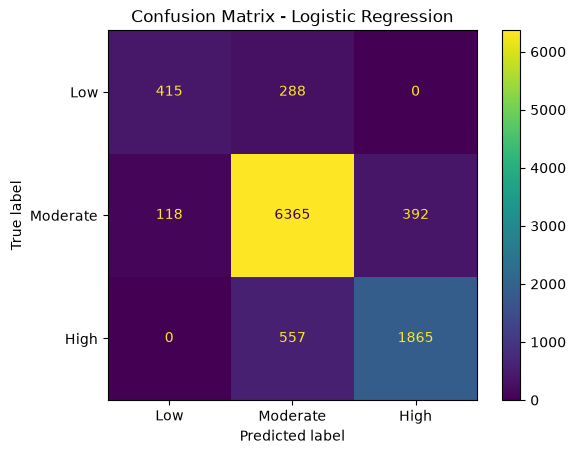

In [287]:
# Create the confusion matrix and adjust label order
confusion_matrix_log = sk.metrics.confusion_matrix(
    y_test,
    y_pred_log,
    labels=["Low", "Moderate", "High"]
)

# Plot the confusion matrix above
sk.metrics.ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_log,
    display_labels=["Low", "Moderate", "High"]
).plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

To summarize the findings from above, the multinomial logistic regression model scored as follows:
- Accuracy: 86%
- Balanced accuracy: 76.2%
- Macro F1: 0.79
- Weighted F1: 0.86

*Note. The Weighted F1 statistic adjusts for the # of cases of Low, Moderate, and High Risk in the dataset*

The model correctly identified 59% of low risk cases, 93% of moderate risk cases, and 77% of high risk cases, but it has issues discriminating between low-moderate and moderate-high risk cases as shown in the confusion matrix.


### Model 2: Random Forest

In [288]:
# Create a random forest model with 300 decision tree classifiers using a random seed
rf_model = sk.ensemble.RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train the model using our processed training data
rf_model.fit(x_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [289]:
# Predict values of Stroke Risk by applying our model to the testing data.
y_pred_rf = rf_model.predict(x_test_processed)

# Report classification metrics of the test
print(sk.metrics.classification_report(y_test, y_pred_rf))

# Calculate and report the balanced accuracy 
balanced_accuracy_rf = sk.metrics.balanced_accuracy_score(y_test, y_pred_rf)

print(f"Balanced accuracy: {balanced_accuracy_rf:.3f}")

              precision    recall  f1-score   support

        High       0.93      0.51      0.66      2422
         Low       1.00      0.10      0.18       703
    Moderate       0.79      0.99      0.88      6875

    accuracy                           0.81     10000
   macro avg       0.91      0.53      0.57     10000
weighted avg       0.84      0.81      0.78     10000

Balanced accuracy: 0.533


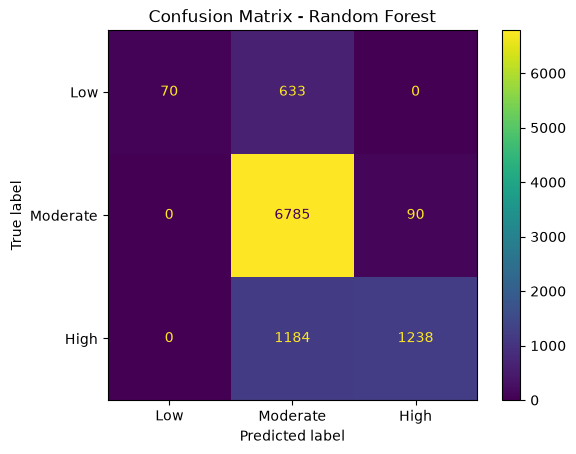

In [290]:
# Create the confusion matrix and adjust label order
confusion_matrix_rf = sk.metrics.confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["Low", "Moderate", "High"]
)

# Plot the confusion matrix above
sk.metrics.ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_rf,
    display_labels=["Low", "Moderate", "High"]
).plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

The random forest model is conservative when predicting Low and High risk outcomes, and performed worse than the logistic regression model overall. This bias may be due to the smaller number of Low and High Risk cases relative to Moderate Risk cases in the training data. To test this hypothesis, we can balance class weights using a weighted random forest model.

### Model 3: Weighted Random Forest

In [291]:
# Create a weighted random forest model with 300 decision tree classifiers using a random seed and balance the class weights
rfw_model = sk.ensemble.RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the model using our processed training data
rfw_model.fit(x_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [292]:
# Predict values of Stroke Risk by applying our model to the testing data.
y_pred_rfw = rfw_model.predict(x_test_processed)

# Report classification metrics of the test
print(sk.metrics.classification_report(y_test, y_pred_rfw))

# Calculate and report the balanced accuracy 
balanced_accuracy_rfw = sk.metrics.balanced_accuracy_score(y_test, y_pred_rfw)

print(f"Balanced accuracy: {balanced_accuracy_rfw:.3f}")

              precision    recall  f1-score   support

        High       0.81      0.79      0.80      2422
         Low       0.94      0.49      0.64       703
    Moderate       0.88      0.93      0.91      6875

    accuracy                           0.87     10000
   macro avg       0.88      0.74      0.78     10000
weighted avg       0.87      0.87      0.86     10000

Balanced accuracy: 0.737


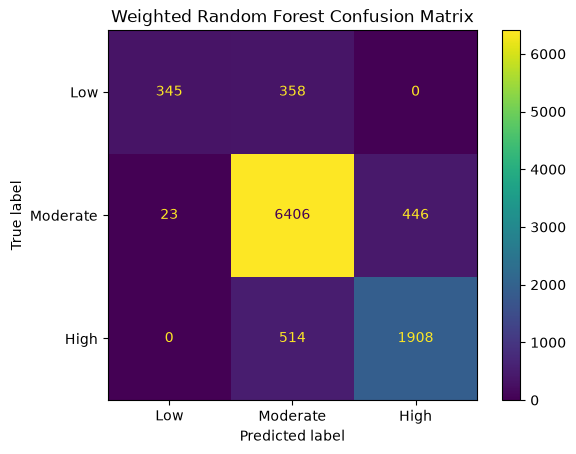

In [293]:
# Create the confusion matrix and adjust label order
confusion_matrix_rfw = sk.metrics.confusion_matrix(
    y_test,
    y_pred_rfw,
    labels=["Low", "Moderate", "High"]
)

# Plot the confusion matrix above
sk.metrics.ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_rfw,
    display_labels=["Low", "Moderate", "High"]
).plot()

plt.title("Weighted Random Forest Confusion Matrix")
plt.show()

Although class weights improved the accuracy of the random forest model by improving minority class performance, it still did not outperform the logistic regression model. Next, we will attempt to tune the model using hyperparameters and cross-validation to see if we can find a better configuration.


### Model 4: Tuned Random Forest

In [294]:
# Determine the parameters to be tested, including number of estimators, maximum depth, and minumum samples in each leaf. We will keep the balanced class weights approach.
rf_param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": ["balanced"]
}

# Create a model by conducting a grid search over all parameter combinations above to identify the combination which produces the highest balanced accuracy.
# Each configuration will be cross-validated using stratified K-Fold validation to test five separate "test" sets from the dataset.
rf_grid_search = sk.model_selection.GridSearchCV(
    estimator=sk.ensemble.RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    cv=sk.model_selection.StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    scoring="balanced_accuracy",
    n_jobs=-1
)

# Train the tuned model using our processed training data
rf_grid_search.fit(x_train_processed, y_train)

# Return the best parameters and the highest average balanced accuracy achieved across the five folds of data.
print("Optimal parameters:", rf_grid_search.best_params_)
print(f"Top balanced accuracy: ", f"{rf_grid_search.best_score_:.3f}")

Optimal parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 300}
Top balanced accuracy:  0.857


Hyperparameterization reveals that the most optimal model (out of the parameters available) achieves a balanced accuracy of 0.857 with a maximum depth of 10, at least 5 samples per lead, 300 estimators, and balanced class weights. We can also identify the individual balanced accuracy metrics for each of the five folds in our cross validation.

In [295]:
# Generate cross validations metrics from the optimal model identified above
rf_cv_results = sk.model_selection.cross_validate(
    rf_grid_search.best_estimator_,
    x_train_processed,
    y_train,
    cv=sk.model_selection.StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    scoring="balanced_accuracy"
)

# Report the balanced accuracy scores of the optimal model for each of the five folds
print(rf_cv_results["test_score"])

[0.85275159 0.85948738 0.86440615 0.85478677 0.85404681]


With those specifications identified, we can continue to build and test the model as before.

In [296]:
# Retrieve the optimal model from the search above
trf_model = rf_grid_search.best_estimator_

# Train the model using our processed training data
trf_model.fit(x_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [297]:
# Predict values of Stroke Risk by applying our model to the testing data.
y_pred_trf = trf_model.predict(x_test_processed)

# Report classification metrics of the test
print(sk.metrics.classification_report(y_test, y_pred_trf))

# Calculate and report the balanced accuracy 
trf_balanced_accuracy = sk.metrics.balanced_accuracy_score(y_test, y_pred_trf)

print(f"Balanced accuracy: {trf_balanced_accuracy:.3f}")

              precision    recall  f1-score   support

        High       0.63      0.93      0.75      2422
         Low       0.41      0.95      0.57       703
    Moderate       0.96      0.67      0.79      6875

    accuracy                           0.75     10000
   macro avg       0.67      0.85      0.70     10000
weighted avg       0.84      0.75      0.76     10000

Balanced accuracy: 0.849


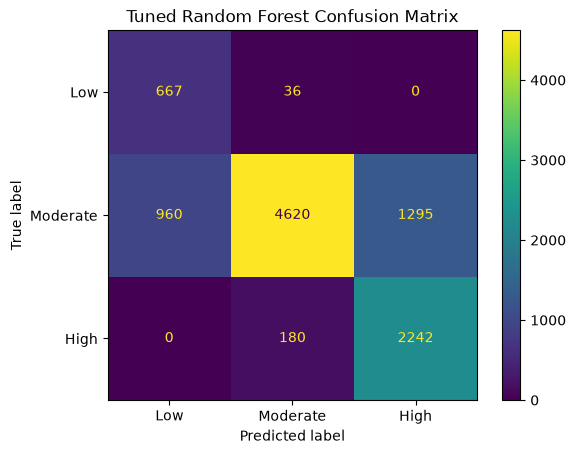

In [298]:
# Create the confusion matrix and adjust label order
confusion_matrix_trf = sk.metrics.confusion_matrix(
    y_test,
    y_pred_trf,
    labels=["Low", "Moderate", "High"]
)

# Plot the confusion matrix above
sk.metrics.ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_trf,
    display_labels=["Low", "Moderate", "High"]
).plot()

plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

The tuned random forest model predicts stroke risk with 84.9% balanced accuracy. Instead of under-predicting low and high risk cases, the recall (i.e., true positive rate, or sensitivity) of the updated model is 95% and 93% for these outcomes, respectively, while the recall of moderate risk cases has dropped from 93% to 67%.

### Model 5: XGBoost

In [299]:
# Create an XGBoost model
xgb_model = xg.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

# Encode the target variable labels into the integers 0, 1, and 2 and fit these labels onto the training and testing target data
label_encoder = sk.preprocessing.LabelEncoder()
y_train_xgb = label_encoder.fit_transform(y_train)
y_test_xgb = label_encoder.transform(y_test)

# Train the model using our processed training data
xgb_model.fit(
    x_train_processed,
    y_train_xgb
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) r

In [300]:
# Predict values of Stroke Risk by applying our model to the testing data.
xgb_pred = xgb_model.predict(x_test_processed)

# Reset the outcome labels to text for readability
xgb_pred_labels = label_encoder.inverse_transform(xgb_pred)

# Report classification metrics of the test
print(sk.metrics.classification_report(y_test, xgb_pred_labels))

# Calculate and report the balanced accuracy 
xgb_balanced_accuracy = sk.metrics.balanced_accuracy_score(y_test, xgb_pred_labels)

print(f"Balanced accuracy: {xgb_balanced_accuracy:.3f}")


              precision    recall  f1-score   support

        High       0.95      0.83      0.89      2422
         Low       0.96      0.61      0.75       703
    Moderate       0.91      0.98      0.94      6875

    accuracy                           0.92     10000
   macro avg       0.94      0.81      0.86     10000
weighted avg       0.92      0.92      0.92     10000

Balanced accuracy: 0.810


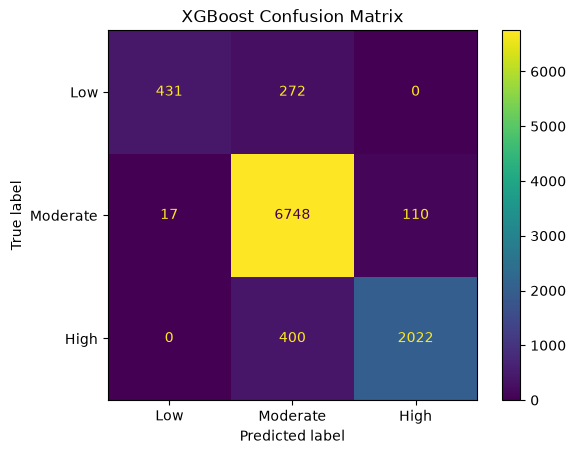

In [301]:
# Create the confusion matrix and adjust label order
xgb_confusion_matrix = sk.metrics.confusion_matrix(
    y_test,
    xgb_pred_labels,
    labels=["Low", "Moderate", "High"]
)

# Plot the confusion matrix above
sk.metrics.ConfusionMatrixDisplay(
    confusion_matrix=xgb_confusion_matrix,
    display_labels=["Low", "Moderate", "High"]
).plot()

plt.title("XGBoost Confusion Matrix")
plt.show()

Despite having a slightly lower balanced accuracy relative to the tuned weighted random forest model, the XGBoost model outperforms all other tested models in terms of overall accuracy.

The confusion matrix also tells us that this model is conservative: it's accurate in predicting moderate-to-high risk cases, but tends to incorrectly elevate low-risk cases. We can again use hyperparameterization and cross-validation to tune this model to try to get better performance.

### Model 6: Tuned XGBoost

In [302]:
# Determine the parameters to be tested, including number of estimators, maximum depth, and minumum samples in each leaf. We will keep the balanced class weights approach.
xgb_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "min_child_weight": [1, 5]
}

# Use 5-fold cross validation to identify the parameters that produce the highest accuracy model
xgb_grid_search = sk.model_selection.GridSearchCV(
    estimator=xg.XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ),
    param_grid=xgb_param_grid,
    cv=sk.model_selection.StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    scoring="balanced_accuracy",
    n_jobs=-1
)

xgb_grid_search.fit(x_train_processed, y_train_xgb)

# Return the best parameters and the highest average balanced accuracy achieved across the five folds of data.
print("Optimal parameters:", xgb_grid_search.best_params_)
print(f"Top balanced accuracy: ", f"{xgb_grid_search.best_score_:.3f}")

Optimal parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 500}
Top balanced accuracy:  0.831


After tuning the XGBoost model, we find that the parameters above provide some modest improvements in accuracy.

In [ ]:
# Retrieve the optimal model from the search above
txgb_model = xgb_grid_search.best_estimator_

# Generate predictions for the test data
y_pred_txgb = txgb_model.predict(x_test_processed)

# Convert the numeric predictions base into labels for interpretation
txgb_pred_labels = label_encoder.inverse_transform(y_pred_txgb)

# Report classification metrics of the test
print(sk.metrics.classification_report(y_test, txgb_pred_labels))

# Calculate and report the balanced accuracy 
txgb_balanced_accuracy = sk.metrics.balanced_accuracy_score(y_test, txgb_pred_labels)

print(f"Balanced accuracy: {txgb_balanced_accuracy:.3f}")

              precision    recall  f1-score   support

        High       0.94      0.85      0.89      2422
         Low       0.96      0.67      0.79       703
    Moderate       0.92      0.98      0.95      6875

    accuracy                           0.93     10000
   macro avg       0.94      0.83      0.88     10000
weighted avg       0.93      0.93      0.92     10000

Balanced accuracy: 0.833


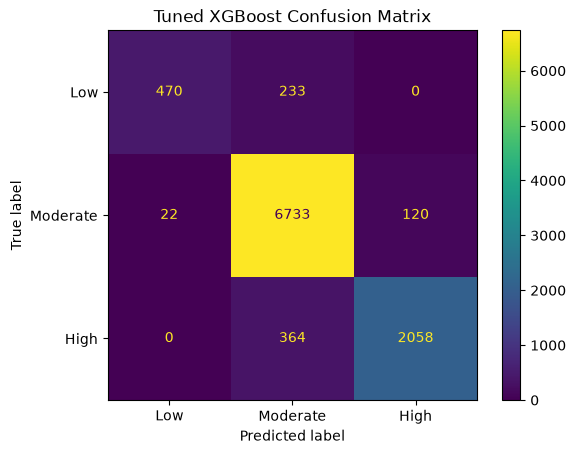

In [304]:
txgb_confusion_matrix = sk.metrics.confusion_matrix(
    y_test,
    txgb_pred_labels,
    labels=["Low", "Moderate", "High"]
)

# Plot the confusion matrix above
sk.metrics.ConfusionMatrixDisplay(
    confusion_matrix=txgb_confusion_matrix,
    display_labels=["Low", "Moderate", "High"]
).plot()

plt.title("Tuned XGBoost Confusion Matrix")
plt.show()

## Step 4 - Model Comparison

With six models, it's now time to compare their ability to classify cases according to predicted stroke-risk status. We will reproduce the metrics we've seen before (i.e., accuracy, balanced accuracy, and macro F1) alongside some additional metrics, including class-specific recall and macro F2. Class-specific recall allows us to see how sensitive each model is to correctly identifying cases within each risk group, while F2 places greater emphasis on recall and therefore penalizes false negatives more heavily than false positives. These metrics will help us identify the model that not only classifies cases accurately, but also minimizes clinically important false negatives (i.e., cases in which a patient who is actually high risk is incorrectly classified as low or moderate risk).

In [305]:
# Store all model predictions
models = {
    "Logistic Regression": y_pred_log,
    "Random Forest": y_pred_rf,
    "Weighted Random Forest": y_pred_rfw,
    "Tuned Random Forest": y_pred_trf,
    "XGBoost": xgb_pred_labels,
    "Tuned XGBoost": txgb_pred_labels
}

# Define the order of the stroke-risk categories
risk_labels = ["Low", "Moderate", "High"]

# Calculate evaluation metrics for each model
model_results = []

for name, predictions in models.items():

    # Calculate recall for each individual risk category
    class_recall = sk.metrics.recall_score(
        y_test,
        predictions,
        labels=risk_labels,
        average=None
    )

    model_results.append({
        "Model": name,

        "Accuracy": sk.metrics.accuracy_score(
            y_test,
            predictions
        ),

        "Balanced Accuracy": sk.metrics.balanced_accuracy_score(
            y_test,
            predictions
        ),

        "Macro F1": sk.metrics.f1_score(
            y_test,
            predictions,
            labels=risk_labels,
            average="macro"
        ),

        "Macro F2": sk.metrics.fbeta_score(
            y_test,
            predictions,
            labels=risk_labels,
            beta=2,
            average="macro"
        ),

        "Low Recall": class_recall[0],
        "Moderate Recall": class_recall[1],
        "High Recall": class_recall[2],

        "Macro Recall": sk.metrics.recall_score(
            y_test,
            predictions,
            labels=risk_labels,
            average="macro"
        )
    })

# Create and display comparison table
model_comparison = pd.DataFrame(model_results)

# Round performance metrics for readability
model_comparison.iloc[:, 1:] = model_comparison.iloc[:, 1:].round(3)

model_comparison.reset_index(drop=True)

,Model,Accuracy,Balanced Accuracy,Macro F1,Macro F2,Low Recall,Moderate Recall,High Recall,Macro Recall
0,Logistic Regression,0.864,0.762,0.791,0.773,0.590,0.926,0.770,0.762
1,Random Forest,0.809,0.533,0.573,0.541,0.100,0.987,0.511,0.533
2,Weighted Random Forest,0.866,0.737,0.783,0.752,0.491,0.932,0.788,0.737
3,Tuned Random Forest,0.753,0.849,0.705,0.771,0.949,0.672,0.926,0.849
4,XGBoost,0.920,0.810,0.860,0.828,0.613,0.982,0.835,0.810
5,Tuned XGBoost,0.926,0.833,0.876,0.848,0.669,0.979,0.850,0.833


Of all the models tested, the Tuned Random Forest model does the best job of identifying low- and high-risk cases, with recall rates of 94.9% and 92.6%, respectively. However, its performance in identifying moderate-risk cases is comparatively lower (67.2%). Conversely, the Tuned XGBoost model demonstrates the strongest overall performance, achieving the highest overall accuracy (92.6%), macro F1 score (87.6%), and macro F2 score (84.8%), while also achieving a high recall for moderate-risk cases (97.9%). Although its recall for low- and high-risk cases is lower than that of the Tuned Random Forest, the Tuned XGBoost provides a stronger overall balance of predictive performance across the three risk categories while minimizing clinically costly false negatives. Therefore, the Tuned XGBoost model will be selected as the final model for additional analyses.

## Step 5 - Model Evaluation and Interpretation

With the final model identified, we can begin to examine the features of the model to determine which ones it relies on to make its predictions. XGBoost provides us with three built-in feature importance metrics for tree-based models: gain, weight, and cover.
- Gain: the average improvement in the model's predictive utility resulting from splits using a feature.
- Weight: how frequently a feature is used for splitting.
- Cover: the average number of observations affected by splits.

### Gain, Weight, and Cover

In [306]:
# Pull the feature names from the preprocessing step
feature_names = preprocessor.get_feature_names_out()

# Remove the preprocessing prefixes for easier interpretation
feature_names = (
    pd.Series(feature_names)
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
    .tolist()
)

# Access the underlying XGBoost booster from the fitted model
booster = txgb_model.get_booster()

# Extract three native XGBoost feature-importance measures:
# Gain: average improvement in the model's objective from splits using the feature
# Weight: number of times the feature is used to create a split
# Cover: average number of observations affected by splits using the feature
gain = booster.get_score(importance_type="gain")
weight = booster.get_score(importance_type="weight")
cover = booster.get_score(importance_type="cover")

# Create a DataFrame containing the importance measures for each feature
xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Gain": [gain.get(f"f{i}", 0) for i in range(len(feature_names))],
    "Weight": [weight.get(f"f{i}", 0) for i in range(len(feature_names))],
    "Cover": [cover.get(f"f{i}", 0) for i in range(len(feature_names))]
})

# Round Gain and Cover to three decimal places
xgb_importance["Gain"] = xgb_importance["Gain"].round(2)
xgb_importance["Cover"] = xgb_importance["Cover"].round(1)

# Convert Weight to integers to remove the trailing .0
xgb_importance["Weight"] = xgb_importance["Weight"].astype(int)

# Rank features by Gain
xgb_importance = xgb_importance.sort_values(
    "Gain",
    ascending=False
)

# Display the 20 features with the highest Gain
xgb_importance.head(20)

,Feature,Gain,Weight,Cover
69,Previous_TIA_No,12.74,825,3819.3
53,Stress_Level_High,11.58,678,1599.9
51,Physical_Activity_Level_Low,11.47,660,1605.9
47,Alcohol_Consumption_Frequently,11.28,743,1471.1
65,Hypertension_No,11.12,792,2049.2
58,Diet_Quality_Poor,10.86,732,1457.9
77,Medication_Adherence_Poor,10.64,729,1515.4
4,Blood_Pressure_Systolic,10.58,2895,897.8
0,Age,10.01,3852,934.6
46,Smoking_Status_Never,9.21,789,1022.7


Splits in the tuned XGBoost's decision trees involving cases with no prior history of transient ischemic attack (i.e., mini-strokes), high stress levels, and low physical activity resulted in the greatest improvements in accuracy on average. However, these features were used for splitting decision trees less frequently than features like age, blood glucose levels, blood pressure, and HbA1c levels.

### Permutation Feature Importance

Permutation feature importance is a model-agnostic inspection technique that involves randomly shuffling the observed values of a given feature and then evaluating how much model performance decreases as a result. Features that are important to the model's predictive performance will generally demonstrate a larger decrease in balanced accuracy when their values are shuffled relative to less importance features. This technique can be used to identify the features on which the model relies most heavily for predictive performance.

#### Ungrouped Features

The XGBoost model used one-hot encoded features to make its predictions, so we will first visualize the importance of these ungrouped features.

In [307]:
# Convert the categorical labels in y_test to numeric values
y_test_xgb = label_encoder.transform(y_test)

# Calculate permutation importance of each feature by randomly shuffling features and observing the resulting loss in balanced accuracy
txgb_permutation = sk.inspection.permutation_importance(
    txgb_model,
    x_test_processed,
    y_test_xgb,
    scoring="balanced_accuracy",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

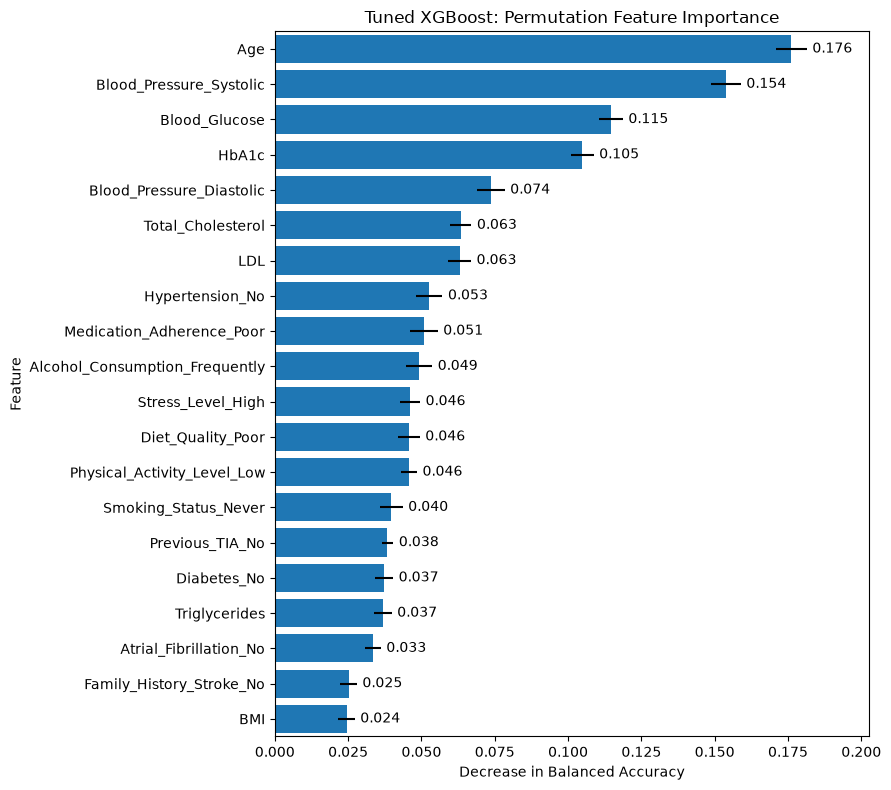

In [308]:
# Store the results in a dataframe alongside the mean and SD of each estimate
permutation_results = pd.DataFrame({ 
    "Feature": feature_names, 
    "Importance_Mean": txgb_permutation.importances_mean, 
    "Importance_SD": txgb_permutation.importances_std 
}) 

# Sort values by mean for visualization
permutation_results = permutation_results.sort_values( 
    "Importance_Mean", 
    ascending=False 
) 

# Remove the data type labels from each feature
permutation_results["Feature"] = ( 
    permutation_results["Feature"] 
    .str.replace("numeric__", "", regex=False) 
    .str.replace("categorical__", "", regex=False) 
) 
 
# Select the 20 most important features for visualization, by mean
top_features = permutation_results.head(20).sort_values( 
    "Importance_Mean" 
) 

 # Create a horizontal bar chart figure to visualize the findings
plt.figure(figsize=(9, 8)) 
 
bars = plt.barh( 
    top_features["Feature"], 
    top_features["Importance_Mean"], 
    xerr=top_features["Importance_SD"] 
) 

# Add data labels to the outside of each bar
plt.bar_label(
    bars,
    fmt="%.3f",
    padding=4
)

# Reduce whitespace
plt.ylim(-0.5, len(top_features) - 0.5)

# Add space to keep data labels inside the chart area
plt.xlim(0, top_features["Importance_Mean"].max() * 1.15)

# Add chart information
plt.xlabel("Decrease in Balanced Accuracy") 
plt.ylabel("Feature") 
plt.title("Tuned XGBoost: Permutation Feature Importance") 
plt.tight_layout() 
plt.show()

#### Grouped Features

Next, we will regroup categorical variables and examing the permutation importance of the original "grouped" features.

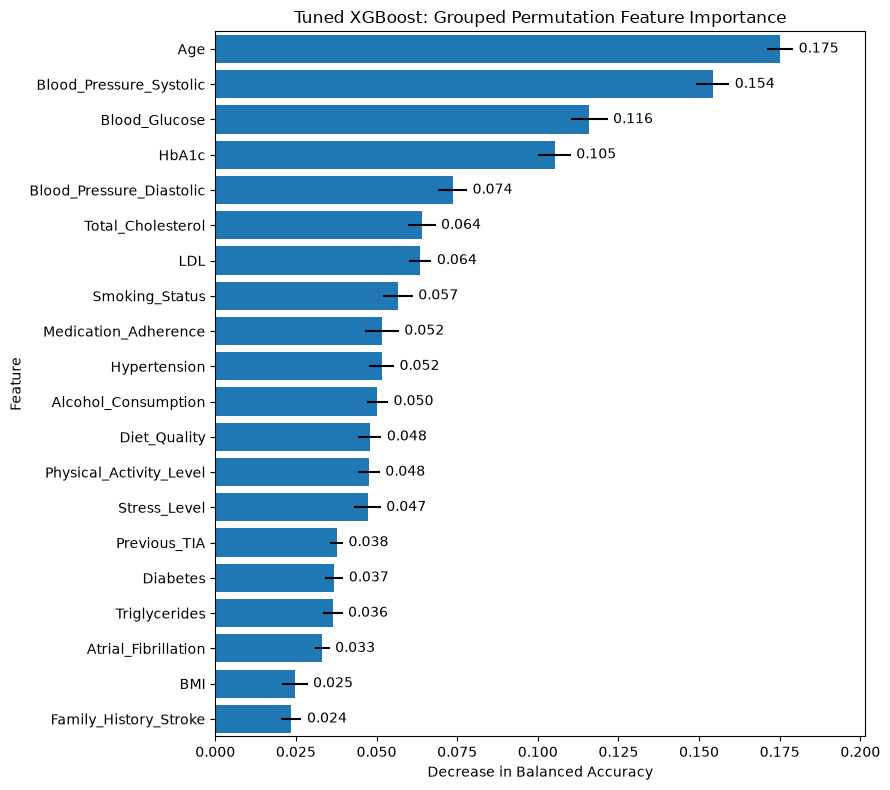

In [309]:

# Convert the processed test data to a NumPy array so that groups of one-hot-encoded features can be permuted together.
if hasattr(x_test_processed, "toarray"):
    x_test_array = x_test_processed.toarray()
else:
    x_test_array = np.asarray(x_test_processed)

# Calculate the model's baseline balanced accuracy on the unpermuted test data
baseline_score = sk.metrics.balanced_accuracy_score(
    y_test_xgb,
    txgb_model.predict(x_test_processed)
)

# Pull the original feature names from the preprocessing object
feature_names = preprocessor.get_feature_names_out()

# Create groups of processed features corresponding to the original variables.
# Numeric variables have one processed feature, while categorical variables may have multiple one-hot-encoded features.
feature_groups = {}

for feature in numeric_features:
    feature_groups[feature] = [
        i for i, name in enumerate(feature_names)
        if name == f"numeric__{feature}"
    ]

for feature in categorical_features:
    feature_groups[feature] = [
        i for i, name in enumerate(feature_names)
        if name.startswith(f"categorical__{feature}_")
    ]

# Calculate grouped permutation importance
grouped_results = []

# Set the number of permutations for each original feature
n_repeats = 30

for feature, indices in feature_groups.items():
    scores = []
    for _ in range(n_repeats):
        # Create a copy of the test data for this permutation
        x_permuted = x_test_array.copy()
        # Use the same row permutation for every one-hot-encoded column belonging to the original categorical variable.
        permutation = np.random.default_rng().permutation(len(x_test_array))
        x_permuted[:, indices] = x_test_array[permutation][:, indices]
        # Calculate balanced accuracy after permuting the feature/group
        permuted_score = sk.metrics.balanced_accuracy_score(
            y_test_xgb,
            txgb_model.predict(x_permuted)
        )

        # Record the decrease in balanced accuracy
        scores.append(baseline_score - permuted_score)

    # Store the mean and standard deviation across permutations
    grouped_results.append({
        "Feature": feature,
        "Importance_Mean": np.mean(scores),
        "Importance_SD": np.std(scores)
    })

# Create and sort the grouped permutation-importance results
grouped_results = pd.DataFrame(grouped_results).sort_values(
    "Importance_Mean",
    ascending=False
)

# Select the 20 most important original variables for visualization
top_grouped = grouped_results.head(20).sort_values(
    "Importance_Mean"
)

# Create the horizontal bar chart
plt.figure(figsize=(9, 8))

bars = plt.barh(
    top_grouped["Feature"],
    top_grouped["Importance_Mean"],
    xerr=top_grouped["Importance_SD"]
)

# Add data labels to the outside of each bar
plt.bar_label(
    bars,
    fmt="%.3f",
    padding=4
)

# Reduce whitespace
plt.ylim(-0.5, len(top_features) - 0.5)

# Extend x-axis to keep data labels inside the chart area
plt.xlim(0, top_grouped["Importance_Mean"].max() * 1.15)

plt.xlabel("Decrease in Balanced Accuracy")
plt.ylabel("Feature")
plt.title("Tuned XGBoost: Grouped Permutation Feature Importance")
plt.tight_layout()
plt.show()

Smoking status rose in the importance rankings after categorical features were regrouped into their original variables, but the top features persisted in similar positions.

### Partial Dependence Plots

Next, we will look at partial dependence plots for our top four features (i.e., age, systolic blood pressure, blood glucose, and HbA1c) to get a sense of the relationship between these features and the target response of our tuned XGBoost model.

#### Predictor 1 - Age

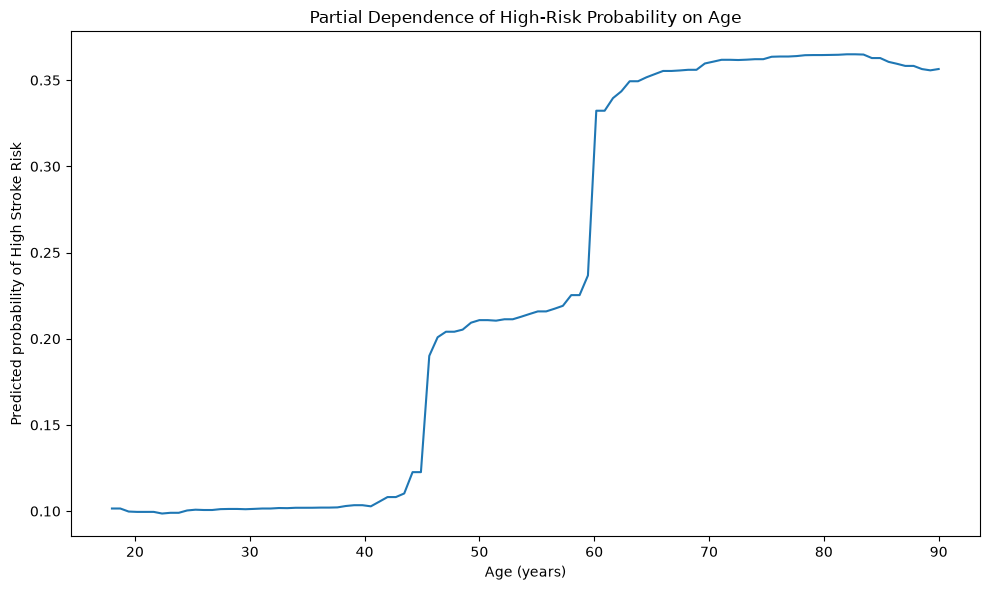

In [310]:
# We need to convert age, which has been standardized, back into interpretable year units.

# Retrieve the scaler object from the numeric data in our preprocessing pipeline
numeric_pipeline = preprocessor.named_transformers_["numeric"]
scaler = numeric_pipeline.named_steps["scaler"]

# Create a pointer to identify the position of age in the list of feature names
age_index = list(feature_names).index("numeric__Age")

# Retrieve the age column from the processed test data
age_values = x_test_processed[:, age_index].copy()

# Covert the age values from the test data back into their original units in years using the scalar obtained earlier
age_values_original = (
    age_values * scaler.scale_[0] + scaler.mean_[0]
)

# Generate a grid of 100 units between the minimum and maximum ages in the dataset
age_grid = np.linspace(18, 90, 100)

# Scale the grid based on the standardized scale used in training
age_grid_scaled = (
    (age_grid - scaler.mean_[0]) / scaler.scale_[0]
)

# Create a list to store predictions
pdp_age_pred = []

# For each age, test how well the model would predict the target variable if everyone was the same age.
for age_scaled in age_grid_scaled:
    # Copy the processed test dataset
    x_temp = x_test_processed.copy()
    # Replace all ages with the scaled age value
    x_temp[:, age_index] = age_scaled
    # Generate probabilities
    probabilities = txgb_model.predict_proba(x_temp)
    # Append the average probabilities
    pdp_age_pred.append(probabilities[:, 0].mean())

# Plot the partial dependence
plt.figure(figsize=(10, 6))
plt.plot(age_grid, pdp_age_pred)
plt.xlabel("Age (years)")
plt.ylabel("Predicted probability of High Stroke Risk")
plt.title("Partial Dependence of High-Risk Probability on Age")
plt.tight_layout()
plt.show()

The partial dependence plot above shows that the XGBoost model is more likely to assign a high risk classification to patients above ~45 years old, and even more likely to assign this classification when patients exceed ~60 years old. The same plot using our logistic regression model might reveal a smoother positive curve, but the decision-tree structure of the XGBoost model yields stepwise patterns of dependence.

#### Predictor 2 - Systolic Blood Pressure

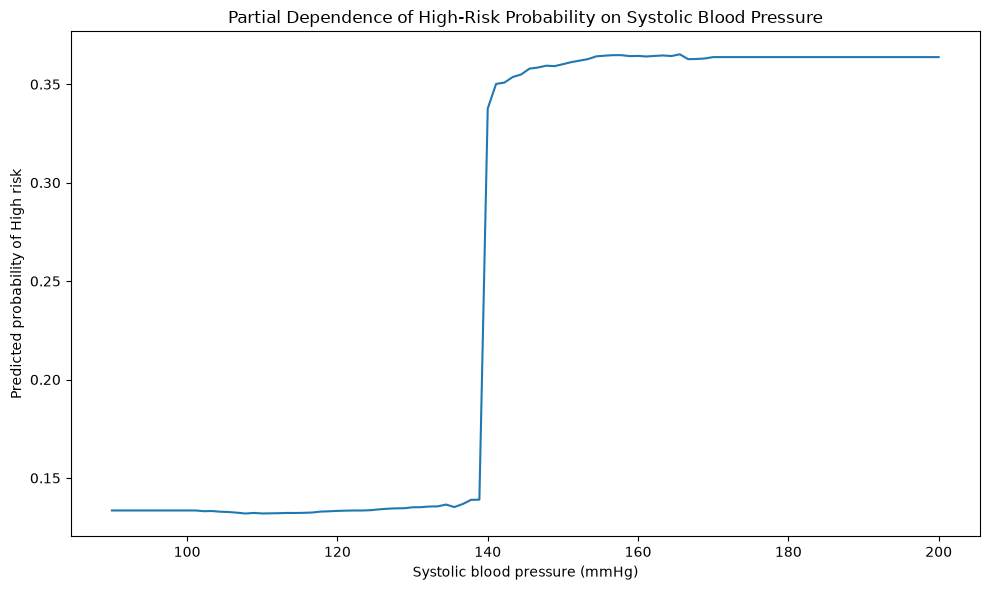

In [311]:
# Identify the position of systolic blood pressure in the list of feature names
sbp_index = list(feature_names).index("numeric__Blood_Pressure_Systolic")

# Identify the position of systolic blood pressure in the list of numeric features
sbp_numeric_index = numeric_features.index("Blood_Pressure_Systolic")

# Generate a grid of 100 units with a range of clinically relevant systolic blood pressure values
sbp_grid = np.linspace(90, 200, 100)

# Standardize the grid using the mean and SD calculated from the training data
sbp_grid_scaled = (
    (sbp_grid - scaler.mean_[sbp_numeric_index])
    / scaler.scale_[sbp_numeric_index]
)

# Create a list to store predictions
pdp_sbp_predictions = []

for sbp_scaled in sbp_grid_scaled:
    # Copy the processed test dataset
    x_temp = x_test_processed.copy()
    # Replace all values with the scaled value
    x_temp[:, sbp_index] = sbp_scaled
    # Generate probabilities
    probabilities = txgb_model.predict_proba(x_temp)
    # Append the average probabilities
    pdp_sbp_predictions.append(probabilities[:, 0].mean())

# Plot the partial dependence
plt.figure(figsize=(10, 6))
plt.plot(sbp_grid, pdp_sbp_predictions)
plt.xlabel("Systolic blood pressure (mmHg)")
plt.ylabel("Predicted probability of High risk")
plt.title("Partial Dependence of High-Risk Probability on Systolic Blood Pressure")
plt.tight_layout()
plt.show()

Unlike the partial dependence plot of age, this plot of systolic blood pressure shows one single inflection point that is used by the model to inform its classification of cases into high risk status. At approximately 140mmHg, the probability of a case being predicted as high risk increases by 20% (i.e., the predicted probability of high risk status is 2.3 times higher for cases at or above 140mmHg of systolic blood pressure than those below).

#### Predictor 3 - Blood Glucose

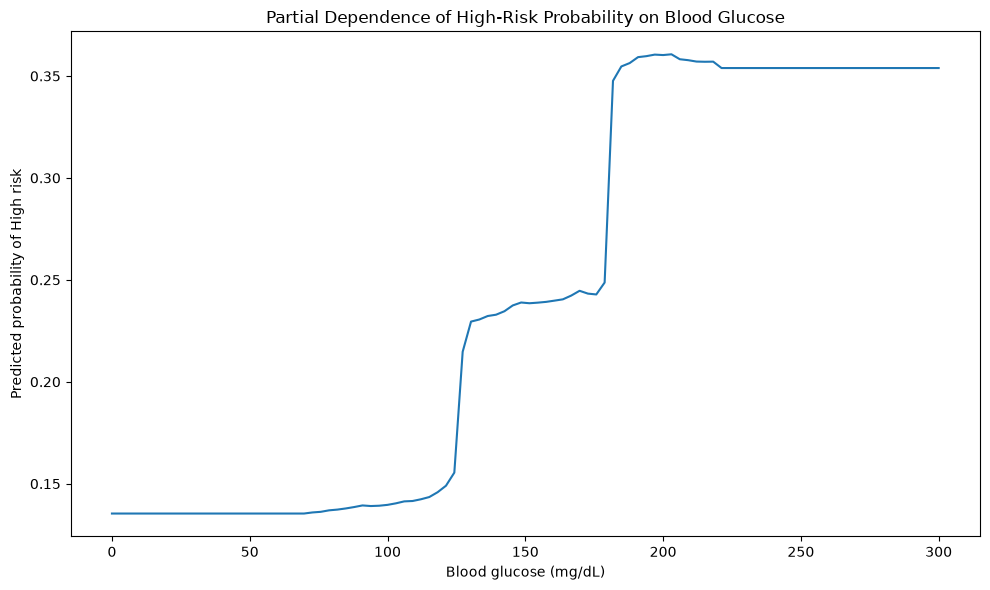

In [312]:
# Identify the position of blood glucose in the list of feature names
glu_index = list(feature_names).index("numeric__Blood_Glucose")

# Identify the position of blood glucose in the list of numeric features
glu_numeric_index = numeric_features.index("Blood_Glucose")

# Generate a grid of 100 units with a range of clinically relevant blood glucose values
glucose_grid = np.linspace(0, 300, 100)

# Standardize the grid using the mean and SD calculated from the training data
glucose_grid_scaled = (
    (glucose_grid - scaler.mean_[glu_numeric_index])
    / scaler.scale_[glu_numeric_index]
)

# Create a list to store predictions
pdp_glu_predictions = []

for glucose_scaled in glucose_grid_scaled:
    # Copy the processed test dataset
    x_temp = x_test_processed.copy()
    # Replace all values with the scaled value
    x_temp[:, glu_index] = glucose_scaled
    # Generate probabilities
    probabilities = txgb_model.predict_proba(x_temp)
    # Append the average probabilities
    pdp_glu_predictions.append(probabilities[:, 0].mean())

# Plot the partial dependence
plt.figure(figsize=(10, 6))
plt.plot(glucose_grid, pdp_glu_predictions)
plt.xlabel("Blood glucose (mg/dL)")
plt.ylabel("Predicted probability of High risk")
plt.title("Partial Dependence of High-Risk Probability on Blood Glucose")
plt.tight_layout()
plt.show()

Similar to the plot of age above, the partial dependence plot of blood glucose reveals two stepwise increases to the predicted probability of the XGBoost model assigning a high risk status to a given case: once at ~125mg/dL, and once again at ~170mg/dL.

#### Predictor 4 - HbA1c

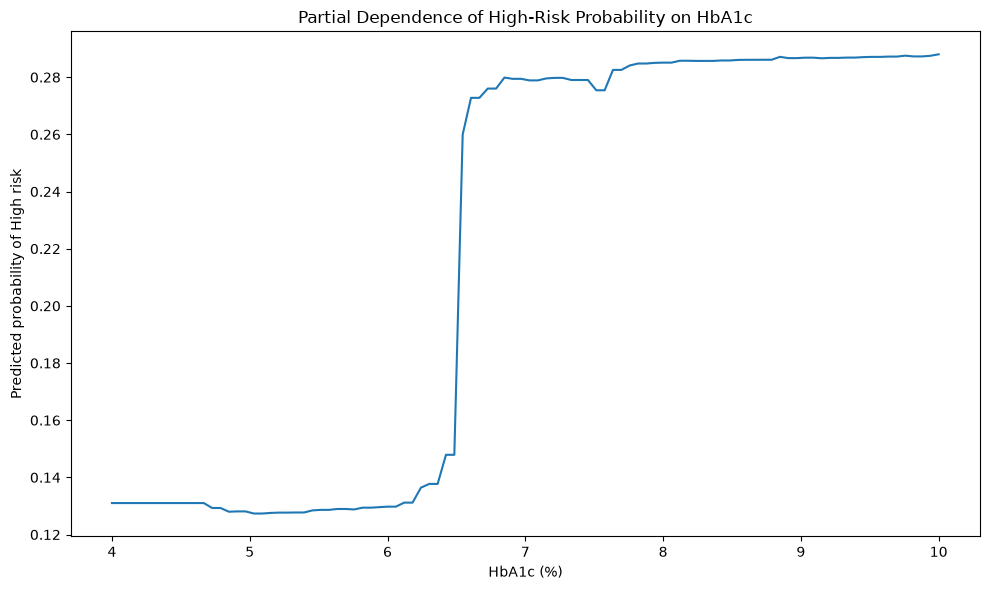

In [313]:
# Identify the position of HbA1c in the list of feature names
hba_index = list(feature_names).index("numeric__HbA1c")

# Identify the position of HbA1c in the list of numeric features
hba_numeric_index = numeric_features.index("HbA1c")

# Generate a grid of 100 units with a range of clinically relevant HbA1c values
hba_grid = np.linspace(4, 10, 100)

# Standardize the grid using the mean and SD calculated from the training data
hba_grid_scaled = (
    (hba_grid - scaler.mean_[hba_numeric_index])
    / scaler.scale_[hba_numeric_index]
)

# Create a list to store predictions
pdp_hba_predictions = []

for hba1c_scaled in hba_grid_scaled:
    # Copy the processed test dataset
    x_temp = x_test_processed.copy()
    # Replace all values with the scaled value
    x_temp[:, hba_index] = hba1c_scaled
    # Generate probabilities
    probabilities = txgb_model.predict_proba(x_temp)
    # Append the average probabilities
    pdp_hba_predictions.append(probabilities[:, 0].mean())

# Plot the partial dependence
plt.figure(figsize=(10, 6))
plt.plot(hba_grid, pdp_hba_predictions)
plt.xlabel("HbA1c (%)")
plt.ylabel("Predicted probability of High risk")
plt.title("Partial Dependence of High-Risk Probability on HbA1c")
plt.tight_layout()
plt.show()

Our final partial dependence plot for HbA1c level looks like the plot above for systolic blood pressure, revealing one inflection point around 6.5% HbA1c that, when exceeded, increases the predicted probability of high risk status by approximately 15%.

### SHAP Analysis

#### Beeswarm Plot

To visualize the individual contribitions of each predictor to the tuned XGBoost model, we can visualize the SHAP values in a beeswarm plot.

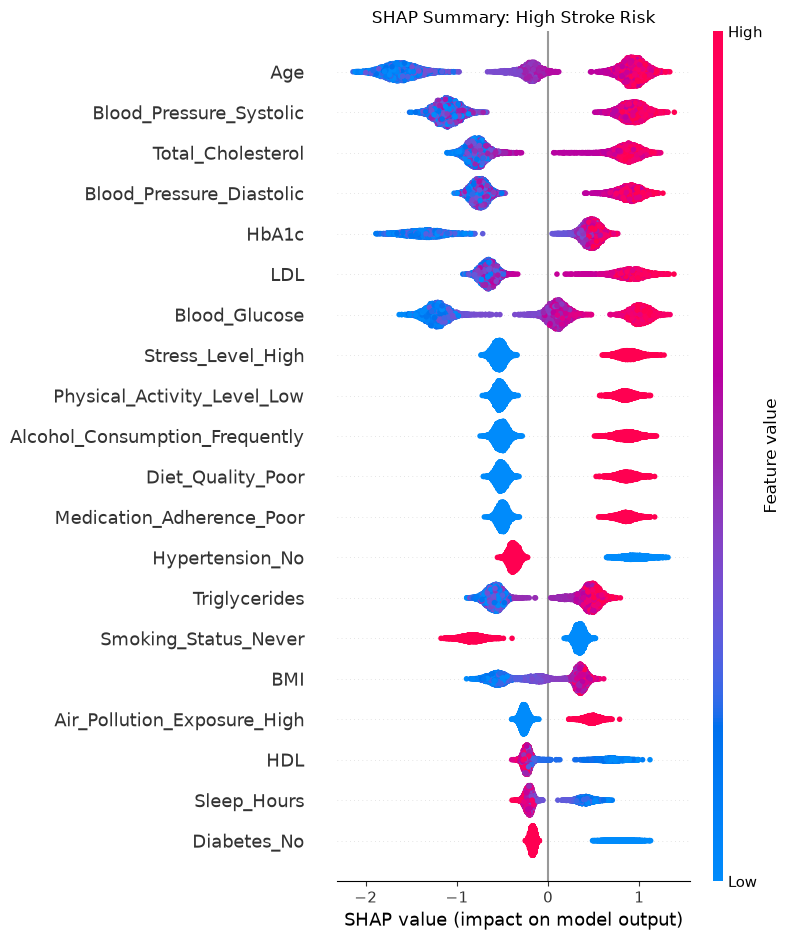

In [316]:
# Remove preprocessing prefixes from feature names for visualization
feature_names_clean = (
    pd.Series(feature_names)
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
    .tolist()
)

# Create a SHAP explainer for the tuned XGBoost model
explainer = shap.TreeExplainer(txgb_model)

# Calculate SHAP values for the processed test data
shap_values = explainer.shap_values(x_test_processed)

# Extract SHAP values for the High Stroke Risk class (i.e., numerically, "0")
shap_high = shap_values[:, :, 0]

# Create a SHAP summary plot for High Stroke Risk
shap.summary_plot(
    shap_high,
    x_test_processed,
    feature_names=feature_names_clean,
    show=False
)

# Visualize the plot
plt.title("SHAP Summary: High Stroke Risk")
plt.tight_layout()
plt.show()

This beeswarm plot above shows how varying levels of each top feature impact the model's determination of high stroke risk status. Cluster color indicates values of the feature, with red indicating high values (e.g., an age of 90, or the categorical statement being "true") and blue indicating low values (i.e., an age of 18, or the categorical statement being "false"). Clusters to the right of the 0 line indicate that the feature (at that value) increases the likelihood of a high risk prediction, while clusters to the left of the 0 line indicate a lower likelihood of a high risk prediction. The shape and spread of each cluster provide information about the effect of the feature at the given value. Dispersed clusters have a wider range of effects, while tight clusters have concentrated effects.

As evidenced by our previous analyses, we see that high values of age, blood pressure (systolic and diastolic), cholesterol, blood glucose, low-density lipoprotein (LDL), and HbA1c all positively predict high risk stroke status determination in the model, and low values of these features predict lower likelihood of this determination. Similarly, high levels of stress, low levels of physical activity, frequent alchohol consumption, poor diet, and poor medication adherance also predict high risk stroke status in the model. For some one-hot encoded categorical variables, we see that the absence of the feature (e.g., no hypertension; no diabetes) results in a lower likelihood of a high risk status determination.

#### SHAP Dependence Plots

We can further investigate SHAP dependence of high stroke risk on age by plotting each age against its SHAP value.

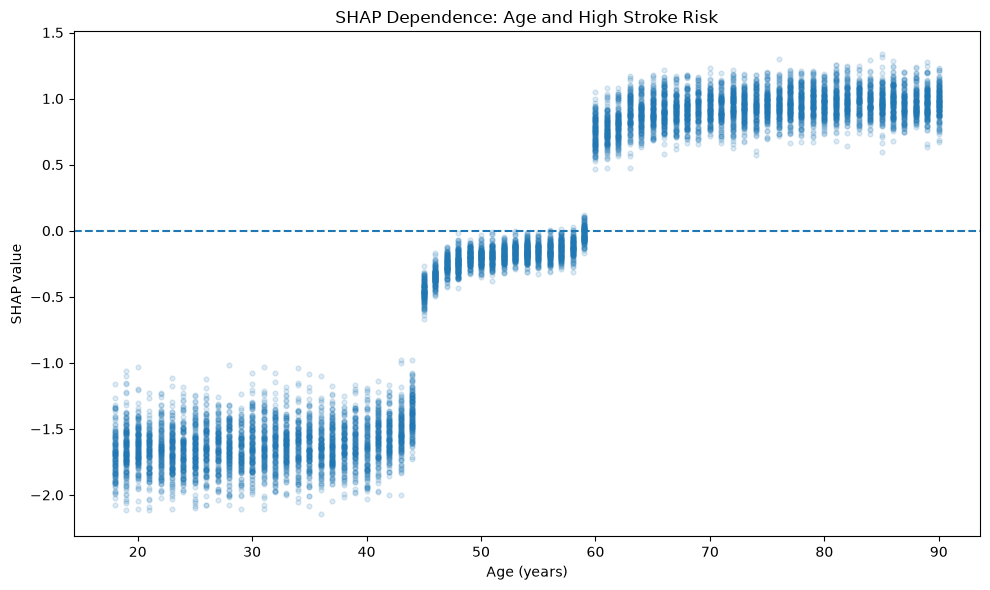

In [318]:
# Convert standardized age values back to years for interpretability
age_original = (
    x_test_processed[:, age_index] * scaler.scale_[0]
    + scaler.mean_[0]
)

# Create a scatterplot of age against SHAP values
plt.figure(figsize=(10, 6))
plt.scatter(
    age_original,
    shap_high[:, age_index],
    alpha=0.15,
    s=12
)

# Format, label, and visualize the plot
plt.axhline(0, linestyle="--")
plt.xlabel("Age (years)")
plt.ylabel("SHAP value")
plt.title("SHAP Dependence: Age and High Stroke Risk")
plt.tight_layout()
plt.show()

The graph above corroborates the nonlinear, threshold-dependent relationship between age and high risk status in the XGBoost model. Now we see that, although there are still two decision-making thresholds, only the one around age 60 pushes the model towards a high risk classification.

Let's visualize one more SHAP dependence plot for systolic blood pressure

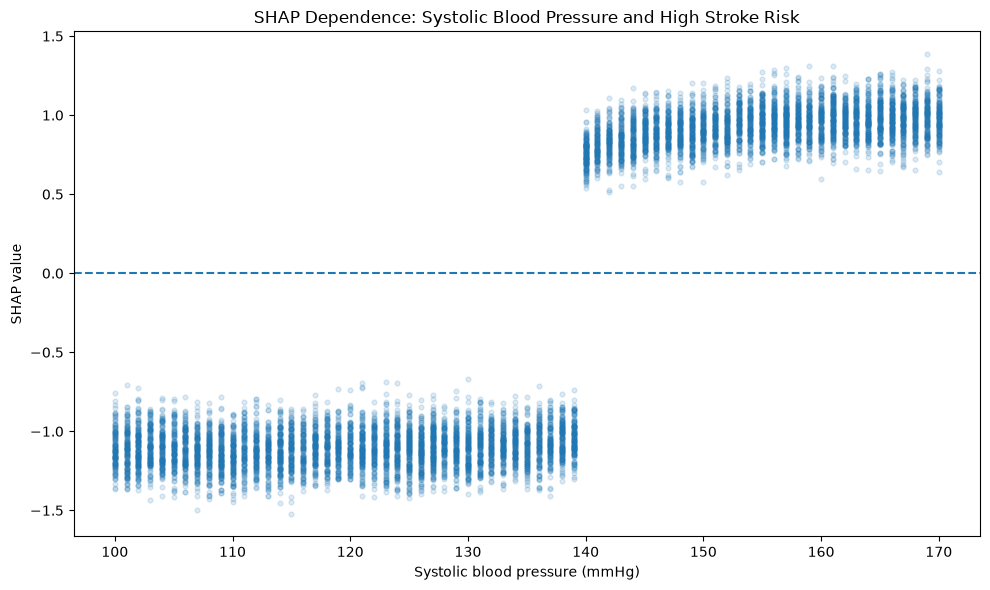

In [320]:
# Identify the position of systolic blood pressure in the processed feature matrix
sbp_index = list(feature_names).index(
    "numeric__Blood_Pressure_Systolic"
)

# Convert standardized systolic blood pressure values back to the original units (mmHg)
sbp_original = (
    x_test_processed[:, sbp_index] * scaler.scale_[4]
    + scaler.mean_[4]
)

# Create a scatterplot of systolic blood pressure against SHAP values
plt.figure(figsize=(10, 6))
plt.scatter(
    sbp_original,
    shap_high[:, sbp_index],
    alpha=0.15,
    s=12
)

# Format, label, and visualize the plot
plt.axhline(0, linestyle="--")
plt.xlabel("Systolic blood pressure (mmHg)")
plt.ylabel("SHAP value")
plt.title("SHAP Dependence: Systolic Blood Pressure and High Stroke Risk")
plt.tight_layout()
plt.show()

The SHAP dependence plot reveals that systolic blood pressure values lower than 140mmHg push the model away from assigning high risk status, while values above this threshold push the model towards assigning the high risk status.

### Calibration

Next, we will create a calibration plot to compares the predicted probabilities of high risk status with the observed proportion of High-risk cases in the test data for some of our different models. This plot will help us identify how well each model is calibrated.

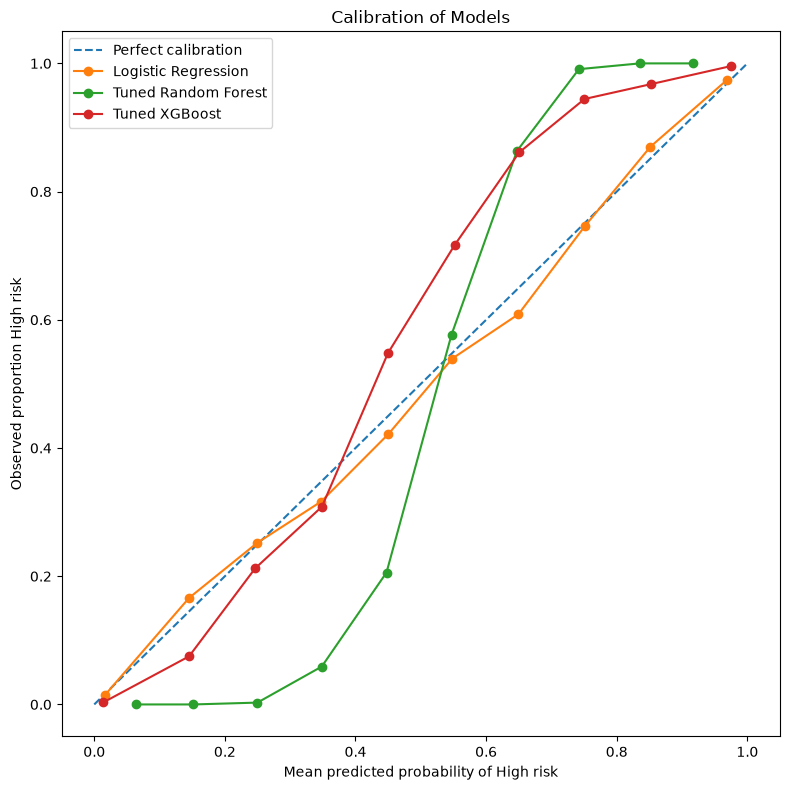

In [ ]:
# Get predicted probabilities for each model
log_probabilities = log_model.predict_proba(x_test_processed)
trf_probabilities = trf_model.predict_proba(x_test_processed)
xgb_probabilities = txgb_model.predict_proba(x_test_processed)

# Convert the observed outcome into a binary indicator (1 = High Stroke Risk, 0 = not High Stroke Risk)
actual_high = (y_test == "High").astype(int)

# Extract the probability of the High-risk class from each model
# Note: XGBoost uses encoded classes, where class 0 corresponds to "High"
high_prob_log = log_probabilities[:, list(log_model.classes_).index("High")]
high_prob_trf = trf_probabilities[:, list(trf_model.classes_).index("High")]
high_prob_xgb = xgb_probabilities[:, 0]

# Calculate calibration data for each model
def get_calibration_data(predicted_probabilities, actual_outcomes):

    calibration_df = pd.DataFrame({
        "Predicted_Probability": predicted_probabilities,
        "Actual_High": actual_outcomes
    })

    calibration_df["Probability_Bin"] = pd.cut(
        calibration_df["Predicted_Probability"],
        bins=np.linspace(0, 1, 11),
        include_lowest=True
    )

    return (
        calibration_df
        .groupby("Probability_Bin", observed=True)
        .agg(
            Mean_Predicted=("Predicted_Probability", "mean"),
            Observed_High=("Actual_High", "mean"),
            Count=("Actual_High", "count")
        )
        .reset_index()
    )

# Calculate calibration data for each model
log_calibration = get_calibration_data(high_prob_log, actual_high)
trf_calibration = get_calibration_data(high_prob_trf, actual_high)
xgb_calibration = get_calibration_data(high_prob_xgb, actual_high)

# Create the calibration plot and add a perfect-calibration reference line
plt.figure(figsize=(8, 8))
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

# Plot each model's calibration curve
plt.plot(
    log_calibration["Mean_Predicted"],
    log_calibration["Observed_High"],
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    trf_calibration["Mean_Predicted"],
    trf_calibration["Observed_High"],
    marker="o",
    label="Tuned Random Forest"
)

plt.plot(
    xgb_calibration["Mean_Predicted"],
    xgb_calibration["Observed_High"],
    marker="o",
    label="Tuned XGBoost"
)

# Format, label, and visualize the plot
plt.xlabel("Mean predicted probability of High risk")
plt.ylabel("Observed proportion High risk")
plt.title("Calibration of Models")
plt.legend()
plt.tight_layout()
plt.show()

The calibration plot indicates that the XGBoost model's probability estimates are not perfectly calibrated. When its curve falls below the reference line, it's telling us that the model is overpredicting the true probability of high risk status. Conversely, when the curve sits above the reference line, it is underpredicting the true probability of high risk status. The sigmodial shape of this calibration line is typical for tree-based models and shows that the XGBoost model is overconfident in its predictions. We can observe a similar, more exaggerated curve sigmoidal curve for the tuned random forest model (another tree-based model). The logistic regression model most closely fits to the perfect calibration reference line, indicating that it appropriately predicts class assignment to the High Risk status. Despite being well calibrated, the logistic regression model did not perform as well as the other two models here earlier in our model comparison.

We can supplement our calibration analysis with two measures of the quality of probabilistic predictions made by each model: Brier score and log loss. **Brier score** is a measure of the mean difference between predicted and expected probabilities for a given outcome. **Log loss** - or in this case, multiclass log loss - measures the mean distance between predicted and expected probability *distributions*, and is thus useful for examining calibration when the target variable contains multiple categories. For both measures, smaller scores indicate better calibration.

In [334]:
# Calculate High-risk Brier scores
high_brier_log = sk.metrics.brier_score_loss(actual_high, high_prob_log)
high_brier_trf = sk.metrics.brier_score_loss(actual_high, high_prob_trf)
high_brier_xgb = sk.metrics.brier_score_loss(actual_high, high_prob_xgb)

# Calculate multiclass log loss
log_loss_log = sk.metrics.log_loss(
    y_test,
    log_probabilities,
    labels=log_model.classes_
)

log_loss_trf = sk.metrics.log_loss(
    y_test,
    trf_probabilities,
    labels=trf_model.classes_
)

log_loss_xgb = sk.metrics.log_loss(
    y_test_xgb,
    xgb_probabilities,
    labels=txgb_model.classes_
)

# Create the summary table
calibration_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Tuned Random Forest",
        "Tuned XGBoost"
    ],
    "High-Risk Brier Score": [
        high_brier_log,
        high_brier_trf,
        high_brier_xgb
    ],
    "Multiclass Log Loss": [
        log_loss_log,
        log_loss_trf,
        log_loss_xgb
    ]
})

# Round the metrics for easier interpretation
calibration_results = calibration_results.round(3)

# Display the results
calibration_results

,Model,High-Risk Brier Score,Multiclass Log Loss
0,Logistic Regression,0.068,0.315
1,Tuned Random Forest,0.117,0.730
2,Tuned XGBoost,0.038,0.191


We see from the table above that the Tuned XGBoost model boasts a smaller Brier score and log loss relative to our other models, both indications of superior calibration.

### Error Analysis

The last step in our model evaluation and interpretation will be identifying how and where the final model makes errors. To accomplish this, we will conduct an error analysis, revisit our confusion matrix, and calculate the total accuracy of the model.

In [349]:
# Create a classification report showing precision, recall, and F1 score for each stroke-risk category
error_analysis = pd.DataFrame(
    sk.metrics.classification_report(
        y_test_xgb,
        y_pred_txgb,
        target_names=label_encoder.classes_,
        output_dict=True
    )
).T

# Keep only the three risk categories
error_analysis = error_analysis.loc[
    label_encoder.classes_,
    ["precision", "recall", "f1-score", "support"]
]

# Rename column headers
error_analysis = error_analysis.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1 Score",
    "support": "Total Cases"
})

# Order the risk classes for intuitive display
risk_order = ["High", "Moderate", "Low"]

print("Performance by Class")
display(error_analysis.loc[risk_order].round(3))

Performance by Class


,Precision,Recall,F1 Score,Total Cases
High,0.945,0.850,0.895,2422.0
Moderate,0.919,0.979,0.948,6875.0
Low,0.955,0.669,0.787,703.0


The tuned XGBoost model performs strongly across the three risk categories, particularly for moderate- and high-risk cases. Although the model's low-risk predictions are precise, its low risk recall is substantially lower. It fails to predicted about a third of low-risk cases. We can revisit our confusion matrix from earlier to understand where these cases are being assigned.

In [350]:
# Calculate the confusion matrix
confusion = sk.metrics.confusion_matrix(
    y_test_xgb,
    y_pred_txgb,
    labels=txgb_model.classes_
)

# Convert the confusion matrix into a labeled DataFrame
confusion_df = pd.DataFrame(
    confusion,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

# Add labels to clearly distinguish actual vs. predicted classes
confusion_df.index.name = "Actual Risk"
confusion_df.columns.name = "Predicted Risk"

# Order the risk classes for intuitive display
risk_order = ["High", "Moderate", "Low"]

print("\nConfusion Matrix")
display(confusion_df.loc[risk_order, risk_order])

# Calculate the number of incorrect predictions
incorrect_predictions = y_test_xgb != y_pred_txgb

print(
    f"\nTotal incorrect predictions: "
    f"{incorrect_predictions.sum():,} "
    f"({incorrect_predictions.mean():.1%} of test observations)"
)


Confusion Matrix


Predicted Risk,High,Moderate,Low
Actual Risk,,,
High,2058,364,0
Moderate,120,6733,22
Low,0,233,470



Total incorrect predictions: 739 (7.4% of test observations)


In total, the model overestimated stroke risk in 353 cases (3.5% of all cases) and underestimated stroke risk in 386 cases (3.9%), for a total error rate of 7.4%.

Ultimately, our tuned XGBoost model predicted stroke risk status in the test data with 92.6% accuracy.

### Wrapup

This project demonstrated an end-to-end machine learning analysis for predicting stroke-risk categories, from data cleaning and exploratory analysis through model development, evaluation, and interpretation. Six classification models were compared, with a tuned XGBoost model selected as the final model based on its overall predictive performance. On the held-out test set, the model correctly classified 92.6% of observations, with particularly strong performance for moderate- and high-risk cases. Feature importance, partial dependence, and SHAP analyses consistently identified variables such as age, systolic blood pressure, blood glucose, and HbA1c as important contributors to model predictions.